# Assignment 1 — CDs & Vinyl


In [ ]:
!pip install emoji

import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# NLP & Preprocessing
import emoji
import html
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif

from sklearn.decomposition import PCA, FastICA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score

RANDOM_STATE = 42
DATA_PATH = "cds_vinyl_50k.csv"  # adjust if you move the notebook relative to the data


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 3.4 MB/s  0:00:00 eta 0:00:01


## 1. Dataset Creation

We loaded the raw review data, dropped duplicate review records to prevent leakage and redundancy, and mapped the star ratings into a binary target by assigning reviews with ratings of 4 or higher to the positive class (1) and those with 3 or fewer stars to the negative class (0).

This established a supervised binary classification framework designed to distinguish satisfied from unsatisfied customer sentiment.

Analyzing the resulting class distribution revealed a severe imbalance of approximately 87.3% positive to 12.7% negative reviews, demonstrating that raw accuracy would be an uninformative, biased evaluation metric and establishing the necessity of adopting macro-averaged F1, balanced accuracy, and cost-sensitive model weighting in later sections.


In [15]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(50000, 10)


,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True
1,1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True
2,2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True
3,3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True
4,4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True


In [16]:
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate reviews (same asin + user_id + text):",
      df.duplicated(subset=["asin", "user_id", "text"]).sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         50000 non-null  int64  
 1   rating             50000 non-null  float64
 2   title              49991 non-null  object 
 3   text               49989 non-null  object 
 4   asin               50000 non-null  object 
 5   parent_asin        50000 non-null  object 
 6   user_id            50000 non-null  object 
 7   timestamp          50000 non-null  int64  
 8   helpful_vote       50000 non-null  int64  
 9   verified_purchase  50000 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(5)
memory usage: 3.5+ MB
None

Missing values per column:
Unnamed: 0            0
rating                0
title                 9
text                 11
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote       

Removed 2803 duplicate records.
Class Balance:
 sentiment
positive    0.866263
negative    0.133737
Name: proportion, dtype: float64


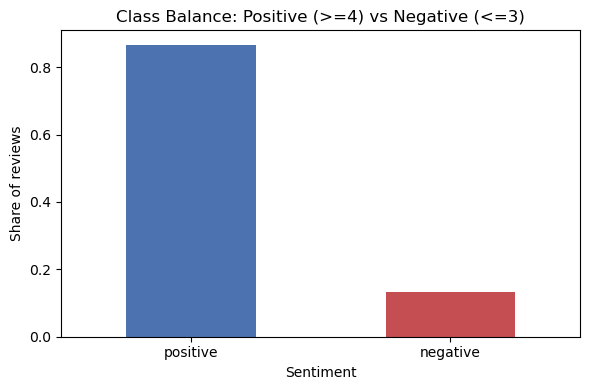

In [17]:
# Drop the column if it exists in the dataframe
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

#Drop duplicate reviews
initial_len = len(df)
df = df.drop_duplicates(subset=['rating', 'text']).copy()
print(f"Removed {initial_len - len(df)} duplicate records.")

#Binary target mapping
df["sentiment"] = (df["rating"] >= 4).astype(int)

#Class balance calculation & visualization
import os
os.makedirs("Report/images", exist_ok=True)
os.makedirs("Report/tables", exist_ok=True)

balance = df["sentiment"].value_counts(normalize=True).rename({0: "negative", 1: "positive"})
print("Class Balance:\n", balance)

plt.figure(figsize=(6, 4))
balance.plot(kind="bar", color=['#4C72B0', '#C44E52'])
plt.title("Class Balance: Positive (>=4) vs Negative (<=3)")
plt.ylabel("Share of reviews")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Report/images/class_balance.png", dpi=150)
plt.show()


Note: in last year's Movies & TV version of this assignment the split was roughly 82k positive vs 19.6k negative (~81/19). Check whether CDs & Vinyl shows a similarly skewed distribution — if so, say explicitly in the report that this affects your choice of evaluation metric later (prefer F1 / balanced accuracy over raw accuracy) and possibly your modeling choice (class_weight="balanced").

## 2. Preprocessing & Analysis

To determine appropriate review inclusion criteria, we audited the dataset for empty inputs, punctuation- or emoji-only entries, and extremely short texts.

We removed the completely empty and punctuation-only records because they contribute zero linguistic or semantic value, while retaining short reviews of two or fewer words since succinct feedback like "great album" carries strong, unambiguous polarity.

Text cleaning was then performed by unescaping HTML entities, removing HTML tags, stripping URLs, removing emojis, lowercasing, and eliminating digits and punctuation. These normalization steps strip non-semantic markup and structural artifacts without destroying sentiment signals, while stemming and lemmatization were intentionally avoided at this stage to preserve subtle morphological distinctions for subsequent vocabulary frequency analysis and bag-of-words representations.

In [18]:
empty_mask = df["text"].isna() | (df["text"].str.strip() == "")
punct_only_mask = df["text"].fillna("").str.fullmatch(r"[\W_]*")
short_mask = df["text"].fillna("").str.split().str.len() <= 2

print("Empty reviews:", empty_mask.sum())
print("Punctuation/emoji-only reviews:", punct_only_mask.sum())
print("Reviews with <=2 words:", short_mask.sum())

# Remove empty and punctuation-only reviews as they carry no textual semantic value.
# Keep reviews with <= 2 words (e.g., "Great album", "Waste money") if they carry clear sentiment polarity.
df_clean = df.loc[~empty_mask & ~punct_only_mask].copy()
print(f"Total reviews retained: {len(df_clean)} out of {len(df)}")


Empty reviews: 6
Punctuation/emoji-only reviews: 34
Reviews with <=2 words: 2039
Total reviews retained: 47163 out of 47197


In [19]:
def clean_text_hybrid(text: str) -> str:
    text = str(text)
    #Unescape HTML entities (converts &quot; -> ", &amp; -> &, etc.)
    text = html.unescape(text)
    #Strip HTML tags like <br />, <div>
    text = re.sub(r"<.*?>", " ", text)
    #Strip URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    #Remove emojis cleanly using emoji library
    text = emoji.replace_emoji(text, replace=" ")
    #Lowercase
    text = text.lower()
    #Normalize contractions (prevent 's' and 't' floating tokens)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    #Strip non-alphabet characters
    text = re.sub(r"[^a-z\s]", " ", text)
    #Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["clean_text"] = df_clean["text"].apply(clean_text_hybrid)
df_clean["tokens"] = df_clean["clean_text"].str.split()
df_clean.head()


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,sentiment,clean_text,tokens
0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True,1,this was a gift for someone,"[this, was, a, gift, for, someone]"
1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True,0,i am in love with the album of uria heep one o...,"[i, am, in, love, with, the, album, of, uria, ..."
2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True,1,not every artist in the music biz just wants t...,"[not, every, artist, in, the, music, biz, just..."
3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True,1,excellent product thank you very much,"[excellent, product, thank, you, very, much]"
4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True,1,this italian beauty has a wonderful angelic op...,"[this, italian, beauty, has, a, wonderful, ang..."


Number of reviews: 47163
Average words per review: 81.00
Number of unique words: 70094


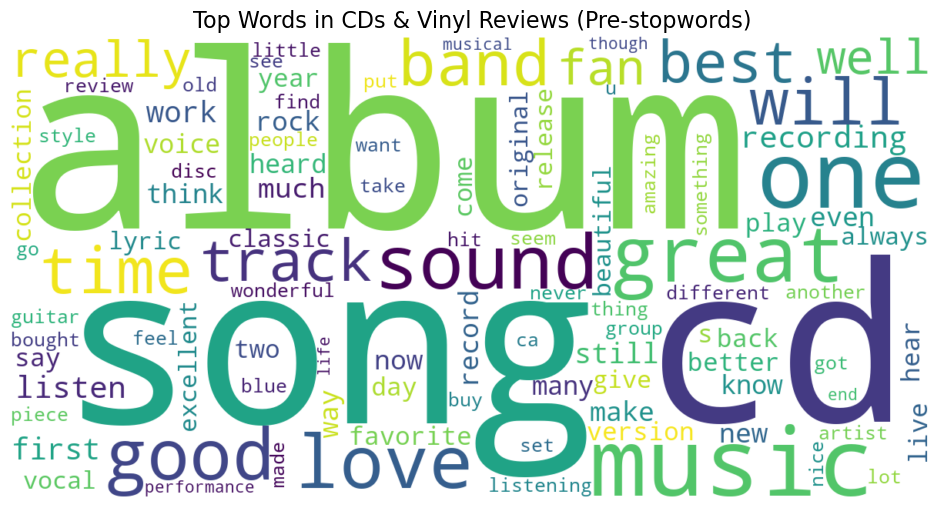

In [20]:
n_reviews = len(df_clean)
avg_words = df_clean["tokens"].str.len().mean()
all_tokens = [w for toks in df_clean["tokens"] for w in toks]
unique_words = len(set(all_tokens))

print(f"Number of reviews: {n_reviews}")
print(f"Average words per review: {avg_words:.2f}")
print(f"Number of unique words: {unique_words}")

# WordCloud visualization from Team 4
wc_text = ' '.join(all_tokens[:200000])  # sample to speed up rendering
wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=100).generate(wc_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in CDs & Vinyl Reviews (Pre-stopwords)", fontsize=16)
plt.savefig("Report/images/wordcloud_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Bag-of-Words Model & Mutual Information

After standardizing the text, we removed standard English stopwords using scikit-learn, extracted the 100 most frequent tokens across the remaining vocabulary, generated a binary document-term occurrence matrix, and computed the mutual information between each feature and the binary sentiment label.

Stripping high-frequency functional words isolates meaningful, content-bearing terms rather than syntactic noise.

Measuring mutual information provides an information-theoretic ranking of token relevance, allowing us to evaluate the statistical dependence of individual words on review sentiment and clearly separate domain-agnostic polarity indicators like "great" and "bad" from music-specific contextual terms like "album" and "sound".


In [21]:
#Filter stopwords
df_clean["tokens_nostop"] = df_clean["tokens"].apply(
    lambda toks: [w for w in toks if w not in ENGLISH_STOP_WORDS and len(w) > 1]
)

#Extract Top 100 most frequent terms
all_words_nostop = [w for toks in df_clean["tokens_nostop"] for w in toks]
top100 = Counter(all_words_nostop).most_common(100)
top100_words = [w for w, _ in top100]
top100_df = pd.DataFrame(top100, columns=["word", "count"])
top100_df.to_csv("Report/tables/top100_words_after_stopwords.csv", index=False)
top100_df.head(20)


,word,count
0,album,29820
1,cd,22859
2,music,20885
3,like,17804
4,great,17775
5,songs,16776
6,song,14321
7,love,12854
8,good,12802
9,just,12214


/opt/anaconda3/envs/AML_env/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/AML_env/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/AML_env/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/AML_env/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values f

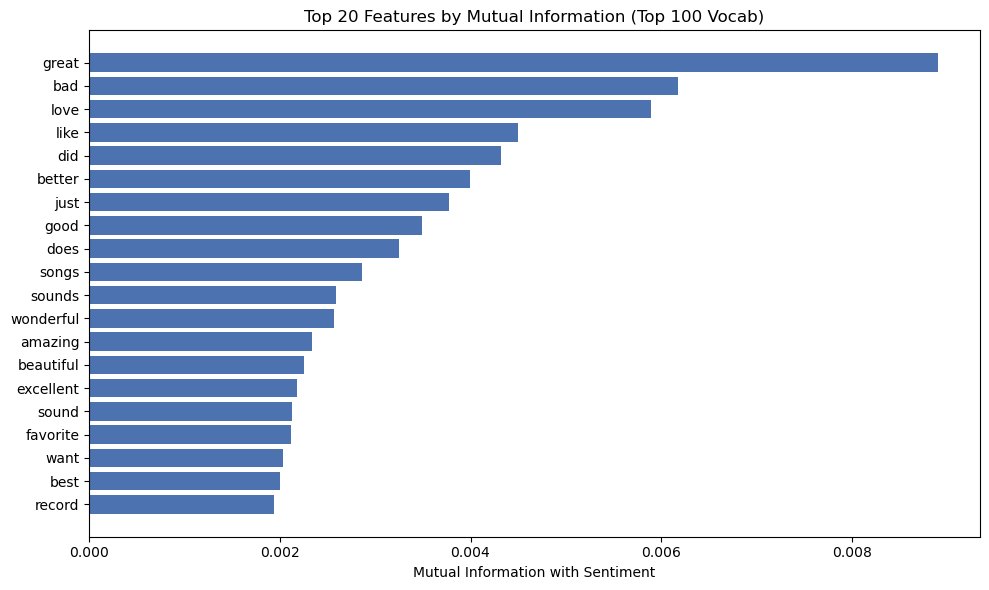

,word,mutual_information
4,great,0.008898
78,bad,0.006173
7,love,0.005897
3,like,0.004496
20,did,0.004316
22,better,0.003991
9,just,0.003773
8,good,0.003487
23,does,0.003247
5,songs,0.002863


In [22]:
#Binary feature matrix for Top 100 vocabulary
top100_vectorizer = TfidfVectorizer(vocabulary=top100_words, use_idf=False, binary=True)
X_top100 = top100_vectorizer.fit_transform(df_clean["clean_text"])

#Compute Mutual Information with sentiment
mi = mutual_info_classif(X_top100, df_clean["sentiment"], discrete_features=True, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"word": top100_words, "mutual_information": mi}).sort_values(
    "mutual_information", ascending=False
)
mi_df.to_csv("Report/tables/top100_mutual_information.csv", index=False)

#Plot Top 20 Mutual Information words for the report
plt.figure(figsize=(10, 6))
plt.barh(mi_df["word"].head(20)[::-1], mi_df["mutual_information"].head(20)[::-1], color="#4C72B0")
plt.xlabel("Mutual Information with Sentiment")
plt.title("Top 20 Features by Mutual Information (Top 100 Vocab)")
plt.tight_layout()
plt.savefig("Report/images/top20_mutual_information.png", dpi=150)
plt.show()

mi_df.head(20)


## 4. Feature Representation

### TF-IDF (top-100 vocabulary) + Logistic Regression


In [12]:
tfidf_vectorizer = TfidfVectorizer(vocabulary=top100_words)
X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

X_tr, X_te, y_tr, y_te = train_test_split(X_tfidf, y, test_size=0.2,
                                           random_state=RANDOM_STATE, stratify=y)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_tfidf.fit(X_tr, y_tr)
print(classification_report(y_te, lr_tfidf.predict(X_te)))


              precision    recall  f1-score   support

           0       0.56      0.05      0.09      1271
           1       0.88      0.99      0.93      8729

    accuracy                           0.87     10000
   macro avg       0.72      0.52      0.51     10000
weighted avg       0.84      0.87      0.83     10000



### Word2Vec — own model vs. pretrained
Train your own Word2Vec on the CDs & Vinyl corpus and compare it against a pretrained model
(e.g. `word2vec-google-news-300` via `gensim.downloader`). Discuss coverage of your
domain-specific vocabulary (e.g. "vinyl", "turntable", "pressing") — this is usually where
the pretrained model underperforms and your own model has an edge.


In [14]:
import gensim
from gensim.models import Word2Vec
import gensim.downloader as gensim_api

# Own model, trained on this corpus
w2v_own = Word2Vec(sentences=df["tokens_nostop"].tolist(), vector_size=100, window=5,
                    min_count=5, workers=4, seed=RANDOM_STATE)

# Pretrained model — downloads on first use (needs network access)
# w2v_pretrained = gensim_api.load("word2vec-google-news-300")

# TODO: compare vocabulary coverage of both models against your corpus vocabulary,
# and compare a handful of nearest-neighbour queries (e.g. w2v_own.wv.most_similar("vinyl")).


**TODO — state which Word2Vec model you choose for the rest of the assignment, and why.**

### Word embeddings → document embeddings


In [15]:
def document_embedding(tokens, model, vector_size):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

VECTOR_SIZE = w2v_own.vector_size
df["doc_embedding"] = df["tokens_nostop"].apply(lambda toks: document_embedding(toks, w2v_own, VECTOR_SIZE))
X_doc_embeddings = np.vstack(df["doc_embedding"].values)
X_doc_embeddings.shape


(50000, 100)

**TODO — explain the averaging choice above** (mean pooling over word vectors) and
mention alternatives you considered (TF-IDF-weighted average, max-pooling, etc.) even if you
didn't implement them.


## 5. Feature Selection & Dimensionality Reduction
Project the Word2Vec **word** embeddings (not document embeddings) to 2D with PCA and ICA.


In [16]:
words = list(w2v_own.wv.index_to_key)
word_vectors = np.array([w2v_own.wv[w] for w in words])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
word_vectors_pca = pca.fit_transform(word_vectors)

ica = FastICA(n_components=2, random_state=RANDOM_STATE)
word_vectors_ica = ica.fit_transform(word_vectors)

# TODO: plot a readable subset (e.g. 200-300 most frequent words, or a hand-picked
# set of sentiment + domain words) with labels, for both PCA and ICA, and compare.


**TODO — discuss whether semantically similar words end up close together** in each
projection, with at least one concrete example pair (e.g. "great"/"excellent" vs.
"scratched"/"damaged"). Note which of PCA or ICA gives a more interpretable picture and why.


## 6. Modeling & Evaluation
Train KNN, Naive Bayes and Logistic Regression on the Word2Vec **document** representations.

Multinomial Naive Bayes requires non-negative features and cannot be used directly on
embeddings (which contain negative values). We use `GaussianNB` instead — TODO: justify
this choice explicitly in the report (assumes features are roughly normally distributed per
class, which is a reasonable approximation for averaged embeddings, unlike raw counts).


In [17]:
X_tr, X_te, y_tr, y_te = train_test_split(X_doc_embeddings, y, test_size=0.2,
                                           random_state=RANDOM_STATE, stratify=y)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    scores = []
    for train_idx, val_idx in cv.split(X_tr):
        model.fit(X_tr[train_idx], y_tr.iloc[train_idx])
        preds = model.predict(X_tr[val_idx])
        scores.append(f1_score(y_tr.iloc[val_idx], preds))
    cv_results[name] = scores
    print(f"{name}: mean CV F1 = {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


KNN: mean CV F1 = 0.9337 (+/- 0.0009)
GaussianNB: mean CV F1 = 0.6320 (+/- 0.0031)
LogisticRegression: mean CV F1 = 0.9338 (+/- 0.0011)


### Hyperparameter search on Logistic Regression

**Important — read this before reporting a number.** The score `GridSearchCV` reports
internally (`.best_score_`) is itself a cross-validated estimate used to *pick* the
hyperparameters. It is not the number you report as your final model's performance —
report that on the held-out test set instead, evaluated once, after the search is done.


In [18]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)
print("Best CV F1 (search score, NOT your final reported score):", grid.best_score_)

best_lr = grid.best_estimator_
test_preds = best_lr.predict(X_te)
print("\nHeld-out test set performance (THIS is what you report as final):")
print(classification_report(y_te, test_preds))


Best params: {'C': 1, 'class_weight': None}
Best CV F1 (search score, NOT your final reported score): 0.933841109474065

Held-out test set performance (THIS is what you report as final):
              precision    recall  f1-score   support

           0       0.55      0.14      0.22      1271
           1       0.89      0.98      0.93      8729

    accuracy                           0.88     10000
   macro avg       0.72      0.56      0.58     10000
weighted avg       0.84      0.88      0.84     10000



### Save the best-performing model
The deliverable requires a single pickled `Pipeline` containing the fitted vectorizer/scaler
*and* the fitted model, so it can predict directly from raw text. TODO: decide whether your
best model is the TF-IDF+LR from Task 4 or the Word2Vec+LR from this task, and build the
matching Pipeline — a raw `LogisticRegression` object alone is not sufficient.


In [ ]:
# Example for the TF-IDF route (adjust if Word2Vec ends up being your best model —
# in that case wrap document_embedding() in a custom sklearn-compatible transformer instead).
best_pipeline = Pipeline([
    ("tfidf", tfidf_vectorizer),
    ("clf", lr_tfidf),
])

with open("Team-X20pickle", "wb") as f:
    pickle.dump(best_pipeline, f)

# Sanity check: load it back and predict on raw text
with open("Team-20.pickle", "rb") as f:
    loaded_pipeline = pickle.load(f)
print(loaded_pipeline.predict(["This album is absolutely amazing, best purchase ever"]))


[1]


**TODO — compare your Word2Vec classifiers (KNN vs GaussianNB vs LR)** side by side
in a small results table, and state which one you'd recommend and why (accuracy alone is not
enough given the class imbalance found in Task 1 — report F1 / balanced accuracy too).


## 7. Clustering & Topic Modeling

### Agglomerative Clustering & DBSCAN on Word2Vec word embeddings


In [20]:
# Use a manageable sample of word vectors (or all of them if small enough)
sample_size = min(2000, len(word_vectors))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(word_vectors), size=sample_size, replace=False)
word_vectors_sample = word_vectors[sample_idx]
words_sample = [words[i] for i in sample_idx]

agg = AgglomerativeClustering(n_clusters=10)
agg_labels = agg.fit_predict(word_vectors_sample)

dbscan = DBSCAN(eps=0.5, min_samples=5)  # TODO: tune eps via a k-distance plot, don't guess
dbscan_labels = dbscan.fit_predict(word_vectors_sample)

print("Agglomerative cluster sizes:", np.bincount(agg_labels))
print("DBSCAN cluster count (excl. noise):", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("DBSCAN noise points:", (dbscan_labels == -1).sum())


Agglomerative cluster sizes: [ 624   46   20   13    2 1201    8   41   44    1]
DBSCAN cluster count (excl. noise): 1
DBSCAN noise points: 803


**TODO — inspect a handful of clusters** (print the words in 3-4 clusters from each
method) and discuss whether they correspond to something meaningful (sentiment, genre,
format-related terms like "vinyl"/"CD"/"turntable", etc).

### Topic Modeling — BERTopic and FuzzyTM

Two practical notes from the assignment brief:
- BERTopic downloads a sentence-transformer model on first use, and accepts precomputed
  embeddings — you can hand it your own Word2Vec/TF-IDF document embeddings instead of
  letting it fetch its default model, which avoids the download entirely if network access
  is a problem.
- FuzzyTM builds dense vocabulary x document matrices and will exhaust an ordinary laptop's
  memory on the full review vocabulary. Prune rare words before fitting it, and **report the
  threshold you used** — this is explicitly asked for.


In [22]:
from bertopic import BERTopic

# Passing precomputed embeddings avoids BERTopic downloading its own sentence-transformer.
docs = df["clean_text"].tolist()
topic_model = BERTopic(embedding_model=None)  # TODO: confirm this signature against your BERTopic version
topics, probs = topic_model.fit_transform(docs, embeddings=X_doc_embeddings)

topic_model.get_topic_info().head(10)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,29919,-1_to_this_it_and,"[to, this, it, and, the, you, album, is, of, t...",[i hate that i waited so long to listen to viv...
1,0,1355,0_quot_amp_the_you,"[quot, amp, the, you, and, of, song, on, is, are]",[for d fans who were introduced to the group a...
2,1,1271,1_recording_symphony_orchestra_performance,"[recording, symphony, orchestra, performance, ...",[carlos chavez has had both the honor and the ...
3,2,808,2_dvd_concert_live_video,"[dvd, concert, live, video, saw, tour, seen, f...","[and a dvd, great cd dvd, great dvd fun concert]"
4,3,724,3_metal_rock_bands_roll,"[metal, rock, bands, roll, band, punk, heavy, ...","[death to all but metal i love this band, this..."
5,4,504,4_don_didn_doesn_know,"[don, didn, doesn, know, care, can, won, like,...",[there are only a couple of good songs on here...
6,5,500,5_fan_big_huge_must,"[fan, big, huge, must, am, fans, gift, collect...","[i am a huge fan, if you re a fan get it but n..."
7,6,251,6_case_cracked_amazon_received,"[case, cracked, amazon, received, item, damage...",[received this cd today and the case is cracke...
8,7,242,7_none_tvm_grt_yip,"[none, tvm, grt, yip, done, aaaaa, boggy, asdm...","[none, none, none]"
9,8,179,8_new_brand_old_love,"[new, brand, old, love, artist, orleans, favor...","[great new music, great new cd, great new album]"


In [23]:
# FuzzyTM — prune the vocabulary first to avoid exhausting memory.
MIN_DOC_FREQ = 20  # TODO: justify this threshold, tune if needed, and report the final value used
word_freq = Counter(w for toks in df["tokens_nostop"] for w in set(toks))
pruned_vocab = {w for w, c in word_freq.items() if c >= MIN_DOC_FREQ}
print(f"Vocabulary pruned from {len(word_freq)} to {len(pruned_vocab)} words (min_doc_freq={MIN_DOC_FREQ})")

# TODO: fit FuzzyTM on the pruned corpus. Consider running this step on a subsample of
# reviews too if memory is still an issue even after pruning.


Vocabulary pruned from 69338 to 7556 words (min_doc_freq=20)


**TODO — evaluate topic quality with an appropriate metric** (e.g. topic coherence,
topic diversity) for both BERTopic and FuzzyTM, and compare them.


## 8. Evaluation & Discussion

**TODO** — pull together, in prose, referencing the tables/figures produced above:
- Which representation (TF-IDF vs Word2Vec-own vs Word2Vec-pretrained) and which classifier
  performed best, with numbers.
- Why you think that happened (dataset size, vocabulary characteristics, class imbalance).
- Limitations of your approach (e.g. mean-pooling loses word order, small training set for
  your own Word2Vec, DBSCAN's sensitivity to `eps`, FuzzyTM's memory constraints).
- Concrete ideas for improvement (e.g. transformer-based embeddings, weighted document
  embeddings, more thorough hyperparameter search, addressing class imbalance directly).
